In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
 
from config.config import N_QUBITS, N_LAYERS, N_POINTS, N_TRIALS, N_EPOCH, N_POPSIZE, N_PM, SEED
from config.experiments import ExperimentConfig
 
from src.data.preprocessing import preprocess
from src.data.saving import (
    RESULTS_DIR, candidate_exists, svm_exists,
    load_parameter_train, load_svm_results,
)
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.classical_base import classical_baseline

In [3]:
# ── 1. Data ────────────────────────────────────────────────────────────────────

dataset = load_breast_cancer()
X_train, X_test, y_train, y_test = preprocess(dataset.data, dataset.target, N_QUBITS)

print(f"Dataset  : {dataset.target_names}")
print(f"Train    : {X_train.shape}  |  Test: {X_test.shape}")

Dataset  : ['malignant' 'benign']
Train    : (398, 4)  |  Test: (171, 4)


In [4]:
# ── 2. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
 
    # ── OPTUNA ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'optuna_random',
        optimizer        = 'optuna',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_global',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name             = 'optuna_nystrom_stratified',
        optimizer        = 'optuna',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_pos': N_POINTS // 2, 'n_neg': N_POINTS // 2},
        optimizer_kwargs = {'n_trials': N_TRIALS},
    ),
 
    # ── MEALPY ────────────────────────────────────────────────────────────────
    ExperimentConfig(
        name             = 'mealpy_random',
        optimizer        = 'mealpy',
        subset_method    = 'random',
        subset_kwargs    = {'n_sample': N_POINTS, 'seed': SEED},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_global',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_global',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_landmarks': N_POINTS},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name             = 'mealpy_nystrom_stratified',
        optimizer        = 'mealpy',
        subset_method    = 'nystrom_stratified',
        subset_kwargs    = {'n_qubits': N_QUBITS, 'n_pos': N_POINTS // 2, 'n_neg': N_POINTS // 2},
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
 
]

In [5]:
# ── 3. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}
 
# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}
 
# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")
 
    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.name).get('g_best', float('nan'))
 
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
 
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
 
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-06-24 20:30:40,239] A new study created in memory with name: no-name-8896a912-8262-4b5b-a7ca-239aa0ae094d



Loaded results of SVM for 'Classical_baseline'

────────────────────────────────────────────────────────────
 optuna_random  [optuna + random]
────────────────────────────────────────────────────────────


[I 2026-06-24 20:30:41,474] Trial 0 finished with value: 5.044965881265668 and parameters: {'gate_0': 'CNOT', 'angle_0': 2.252057207723972, 'gate_1': 'RX', 'angle_1': 3.8954536435184184, 'gate_2': 'H', 'angle_2': 3.5064232260429695, 'gate_3': 'RZ', 'angle_3': 1.4125653904361168, 'gate_4': 'I', 'angle_4': 2.4265604055135817, 'gate_5': 'I', 'angle_5': 1.9993493220441811, 'gate_6': 'H', 'angle_6': 0.08508453934990319, 'gate_7': 'RY', 'angle_7': 4.915190325637625, 'gate_8': 'I', 'angle_8': 2.6843095299243878, 'gate_9': 'CNOT', 'angle_9': 1.1081971136935589, 'gate_10': 'RZ', 'angle_10': 5.698999188699087, 'gate_11': 'RZ', 'angle_11': 0.9377633788078271, 'gate_12': 'RY', 'angle_12': 5.258545348393755, 'gate_13': 'RZ', 'angle_13': 3.4485712199134015, 'gate_14': 'RX', 'angle_14': 1.5075261136953095, 'gate_15': 'CNOT', 'angle_15': 4.907125115317015}. Best is trial 0 with value: 5.044965881265668.
[I 2026-06-24 20:30:42,487] Trial 1 finished with value: 3.1962572846958532 and parameters: {'gate_

Saved candidate  → Results/optuna_random/candidate.pkl
Computing cross-kernel (test × subset)…


[I 2026-06-24 20:33:30,215] A new study created in memory with name: no-name-e4fd819e-0228-44f8-8de6-839fb98d2589


...

Saved candidate  → Results/mealpy_nystrom_global/candidate.pkl
Computing cross-kernel (test × subset)…


/Users/martadelarosanunez/Github/Automatic_Design_QFM_Genomic_Classification/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Users/martadelarosanunez/Github/Automatic_Design_QFM_Genomic_Classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/martadelarosanunez/Github/Automatic_Design_QFM_Genomic_Classification/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifie

Saved SVM        → Results/mealpy_nystrom_global/svm.pkl

REPORT: mealpy_nystrom_global | 30 epochs | 20 pop | 0.1 pm
Best C            : 0.1
Best CV accuracy  : 0.9000
Test accuracy     : 0.3684
              precision    recall  f1-score   support

          -1       0.37      1.00      0.54        63
           1       0.00      0.00      0.00       108

    accuracy                           0.37       171
   macro avg       0.18      0.50      0.27       171
weighted avg       0.14      0.37      0.20       171


────────────────────────────────────────────────────────────
 mealpy_nystrom_stratified  [mealpy + nystrom_stratified]
────────────────────────────────────────────────────────────


2026/06/24 08:59:11 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 9.511533538211847, Global best: 9.683513377645898, Runtime: 16.89340 seconds
2026/06/24 08:59:28 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 9.076983992664372, Global best: 9.683513377645898, Runtime: 17.41422 seconds
2026/06/24 08:59:46 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 8.884478796196964, Global best: 9.683513377645898, Runtime: 18.16674 seconds
2026/06/24 09:00:05 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 10.672568530503685, Global best: 10.672568530503685, Runtime: 19.29693 seconds
2026/06/24 09:00:25 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 10.79363845517596, Global best: 10.79363845517596, Runtime: 19.21071 seconds
2026/06/24 09:00:44 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, E

Saved candidate  → Results/mealpy_nystrom_stratified/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/mealpy_nystrom_stratified/svm.pkl

REPORT: mealpy_nystrom_stratified | 30 epochs | 20 pop | 0.1 pm
Best C            : 1
Best CV accuracy  : 0.9000
Test accuracy     : 0.7895
              precision    recall  f1-score   support

          -1       1.00      0.43      0.60        63
           1       0.75      1.00      0.86       108

    accuracy                           0.79       171
   macro avg       0.88      0.71      0.73       171
weighted avg       0.84      0.79      0.76       171



In [6]:
# ── 4. Summary table ───────────────────────────────────────────────────────────
 
def print_summary(summary: dict) -> None:
    W = 32
    print(f"\n{'═' * 68}")
    print(f"  {'EXPERIMENT':<{W}} {'TEST ACC':>9} {'CV ACC':>9} {'g_best':>9} {'best C':>6}")
    print(f"{'─' * 68}")
    for name, s in summary.items():
        g = f"{s['g_best']:9.2f}" if not np.isnan(s['g_best']) else f"{'—':>9}"
        print(f"  {name:<{W}} {s['accuracy']:>9.4f} {s['cv_acc']:>9.4f} {g} {s['best_C']:>6}")
    print(f"{'═' * 68}\n")
 
print_summary(summary)


════════════════════════════════════════════════════════════════════
  EXPERIMENT                        TEST ACC    CV ACC    g_best best C
────────────────────────────────────────────────────────────────────
  Classical_baseline                  0.9649    0.9547         —   1000
  optuna_random                       0.6023    0.6500     71.66     10
  optuna_nystrom_global               0.3684    0.9000      8.76    0.1
  optuna_nystrom_stratified           0.5906    0.5500     37.33    0.1
  mealpy_random                       0.7836    0.9000     37.83    100
  mealpy_nystrom_global               0.3684    0.9000      8.32    0.1
  mealpy_nystrom_stratified           0.7895    0.9000     18.11      1
════════════════════════════════════════════════════════════════════



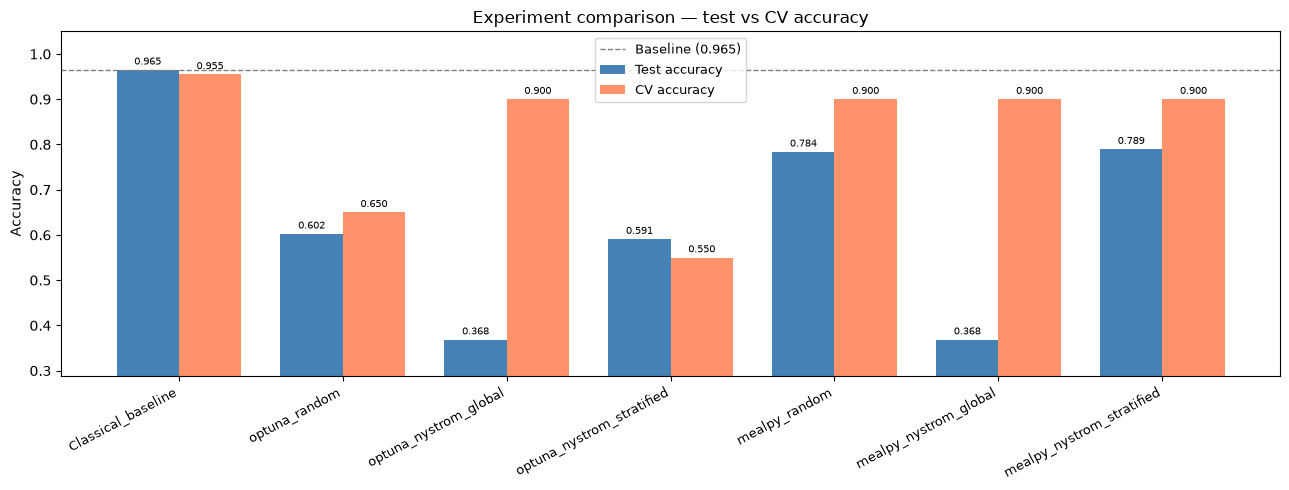

Saved → Results/accuracy_comparison.png


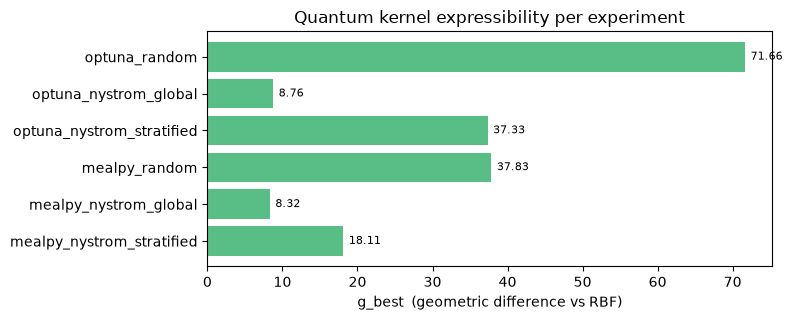

Saved → Results/g_best_comparison.png


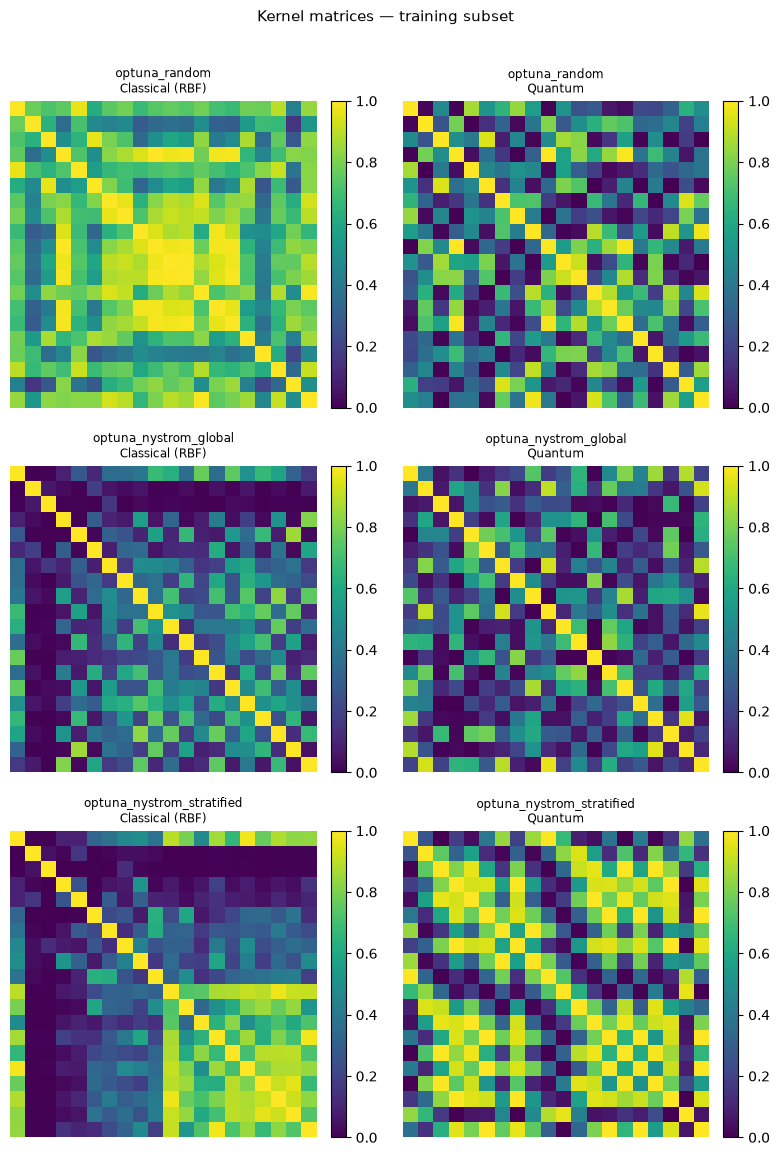

Saved → Results/kernel_heatmaps.png


In [7]:
# ── 5. Visualizations ──────────────────────────────────────────────────────────

def plot_accuracy(summary: dict) -> None:
    """Grouped bar chart: test accuracy vs CV accuracy for every experiment."""
    names     = list(summary.keys())
    test_acc  = [s['accuracy'] for s in summary.values()]
    cv_acc    = [s['cv_acc']   for s in summary.values()]
    baseline  = summary[BASELINE]['accuracy']
 
    x, w = np.arange(len(names)), 0.38
    fig, ax = plt.subplots(figsize=(13, 5))
 
    b1 = ax.bar(x - w/2, test_acc, w, label='Test accuracy', color='steelblue')
    b2 = ax.bar(x + w/2, cv_acc,   w, label='CV accuracy',   color='coral', alpha=0.85)
    ax.axhline(baseline, color='grey', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.3f})')
 
    ax.bar_label(b1, fmt='%.3f', fontsize=7.5, padding=2)
    ax.bar_label(b2, fmt='%.3f', fontsize=7.5, padding=2)
 
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=28, ha='right', fontsize=9)
    ax.set_ylim(max(0, min(test_acc + cv_acc) - 0.08), 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_title('Experiment comparison — test vs CV accuracy')
    ax.legend(fontsize=9)
 
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/accuracy_comparison.png', dpi=150)
    plt.show()
    print(f"Saved → {RESULTS_DIR}/accuracy_comparison.png")
 
 
def plot_g_best(summary: dict) -> None:
    """Horizontal bar chart of geometric difference (g_best) — quantum experiments only."""
    quantum = {k: v for k, v in summary.items() if not np.isnan(v['g_best'])}
    if not quantum:
        return
 
    names  = list(quantum.keys())
    values = [v['g_best'] for v in quantum.values()]
 
    fig, ax = plt.subplots(figsize=(8, max(3, len(names) * 0.55)))
    bars = ax.barh(names, values, color='mediumseagreen', alpha=0.85)
    ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=8)
    ax.set_xlabel('g_best  (geometric difference vs RBF)')
    ax.set_title('Quantum kernel expressibility per experiment')
    ax.invert_yaxis()
 
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/g_best_comparison.png', dpi=150)
    plt.show()
    print(f"Saved → {RESULTS_DIR}/g_best_comparison.png")
 
 
def plot_kernel_heatmaps(summary: dict, max_show: int = 3) -> None:
    """
    Side-by-side kernel heatmaps (classical vs quantum) for the first
    `max_show` quantum experiments. Loads K_quantum and K_classical
    directly from the saved candidate pkls.
    """
    quantum_names = [k for k in summary if k != BASELINE][:max_show]
    n = len(quantum_names)
    if n == 0:
        return
 
    fig, axes = plt.subplots(n, 2, figsize=(8, 3.8 * n), squeeze=False)
 
    for i, name in enumerate(quantum_names):
        if not candidate_exists(name):
            continue
        data = load_parameter_train(name)
        K_c, K_q = data['K_classical'], data['K_quantum']
 
        for j, (K, title) in enumerate([(K_c, 'Classical (RBF)'), (K_q, 'Quantum')]):
            im = axes[i][j].imshow(K, cmap='viridis', vmin=0, vmax=1)
            axes[i][j].set_title(f'{name}\n{title}', fontsize=8.5)
            axes[i][j].axis('off')
            plt.colorbar(im, ax=axes[i][j], fraction=0.046, pad=0.04)
 
    plt.suptitle('Kernel matrices — training subset', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/kernel_heatmaps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {RESULTS_DIR}/kernel_heatmaps.png")

plot_accuracy(summary)
plot_g_best(summary)
plot_kernel_heatmaps(summary, max_show=3)